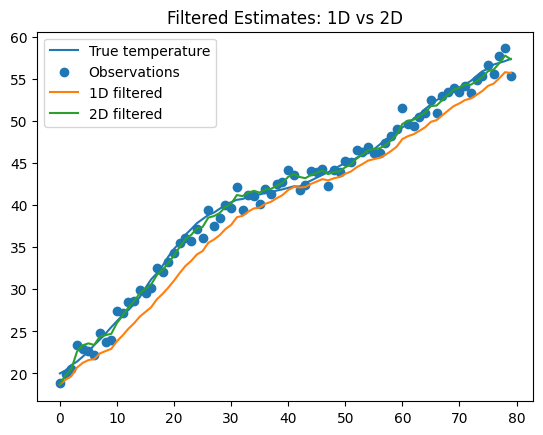

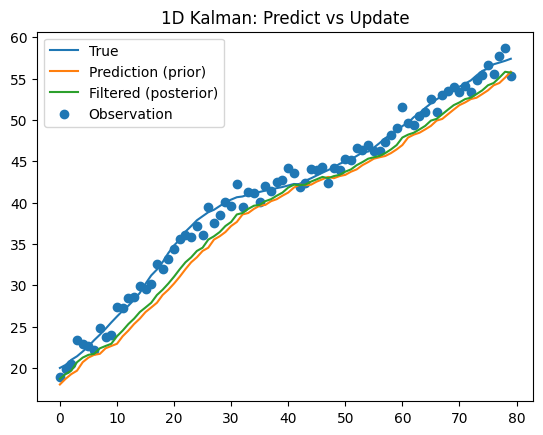

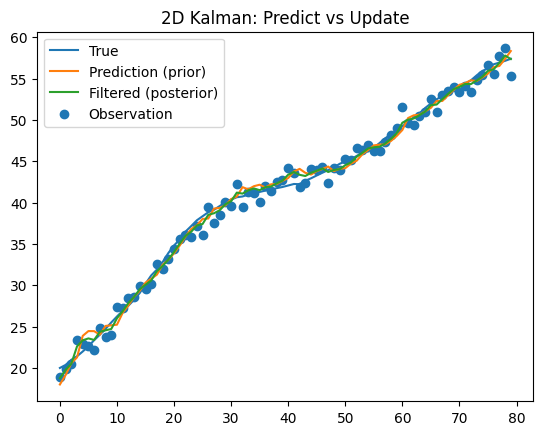

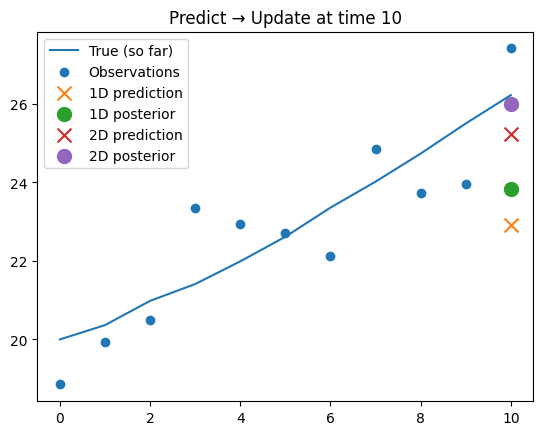

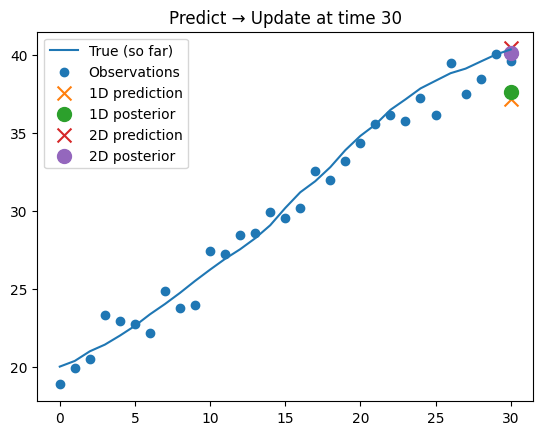

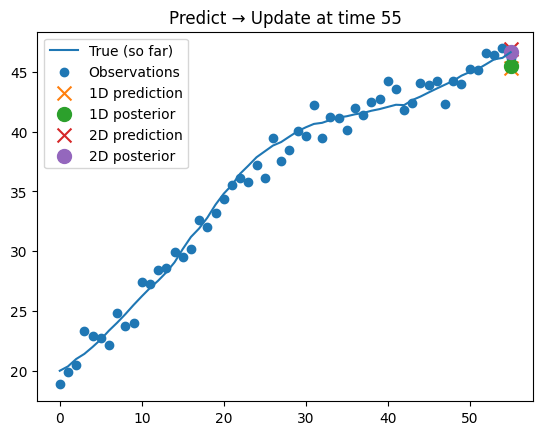

1D RMSE: 2.111253085368334
2D RMSE: 0.5734127169773631


In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ============================================================
# 1. Generate data from true position + velocity model
# ============================================================

n = 80

x_true = np.zeros(n)
v_true = np.zeros(n)

x_true[0] = 20.0
v_true[0] = 0.2

q_pos = 0.01
q_vel = 0.005
r = 1.0

for t in range(1, n):
    v_true[t] = v_true[t-1] + np.random.normal(0, np.sqrt(q_vel))
    x_true[t] = x_true[t-1] + v_true[t] + np.random.normal(0, np.sqrt(q_pos))

z_obs = x_true + np.random.normal(0, np.sqrt(r), size=n)


# ============================================================
# 2. 1D Kalman Filter (random walk model)
# ============================================================

def predict_1d(mean, var, q):
    return mean, var + q

def update_1d(mean, var, z, r):
    K = var / (var + r)
    mean = mean + K * (z - mean)
    var = (1 - K) * var
    return mean, var

q_1d = 0.05  # tuned but still misspecified

mean = 18.0
var = 4.0

pred_1d = []
filt_1d = []
var_pred_1d = []
var_filt_1d = []

for z in z_obs:
    mean, var = predict_1d(mean, var, q_1d)
    pred_1d.append(mean)
    var_pred_1d.append(var)

    mean, var = update_1d(mean, var, z, r)
    filt_1d.append(mean)
    var_filt_1d.append(var)

pred_1d = np.array(pred_1d)
filt_1d = np.array(filt_1d)


# ============================================================
# 3. 2D Kalman Filter (position + velocity)
# ============================================================

dt = 1.0

F = np.array([[1, dt],
              [0, 1]])

H = np.array([[1, 0]])

Q = np.array([[0.01, 0],
              [0, 0.005]])

R = np.array([[r]])

x = np.array([18.0, 0.0])
P = np.eye(2) * 4.0

pred_2d = []
filt_2d = []
var_pred_2d = []
var_filt_2d = []

for z in z_obs:
    # Predict
    x = F @ x
    P = F @ P @ F.T + Q

    pred_2d.append(x[0])
    var_pred_2d.append(P[0,0])

    # Update
    y = z - H @ x
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    x = x + K @ y
    P = (np.eye(2) - K @ H) @ P

    filt_2d.append(x[0])
    var_filt_2d.append(P[0,0])

pred_2d = np.array(pred_2d)
filt_2d = np.array(filt_2d)


# ============================================================
# 4. Full time-series comparison
# ============================================================

plt.figure()
plt.plot(x_true, label="True temperature")
plt.scatter(range(n), z_obs, label="Observations")
plt.plot(filt_1d, label="1D filtered")
plt.plot(filt_2d, label="2D filtered")
plt.legend()
plt.title("Filtered Estimates: 1D vs 2D")
plt.show()


# ============================================================
# 5. Prediction vs Update (1D)
# ============================================================

plt.figure()
plt.plot(x_true, label="True")
plt.plot(pred_1d, label="Prediction (prior)")
plt.plot(filt_1d, label="Filtered (posterior)")
plt.scatter(range(n), z_obs, label="Observation")
plt.legend()
plt.title("1D Kalman: Predict vs Update")
plt.show()


# ============================================================
# 6. Prediction vs Update (2D)
# ============================================================

plt.figure()
plt.plot(x_true, label="True")
plt.plot(pred_2d, label="Prediction (prior)")
plt.plot(filt_2d, label="Filtered (posterior)")
plt.scatter(range(n), z_obs, label="Observation")
plt.legend()
plt.title("2D Kalman: Predict vs Update")
plt.show()


# ============================================================
# 7. Snapshot panels at selected time steps
# ============================================================

snapshot_times = [10, 30, 55]

for t in snapshot_times:
    plt.figure()
    plt.plot(x_true[:t+1], label="True (so far)")
    plt.scatter(range(t+1), z_obs[:t+1], label="Observations")

    plt.scatter(t, pred_1d[t], marker='x', s=100, label="1D prediction")
    plt.scatter(t, filt_1d[t], marker='o', s=100, label="1D posterior")

    plt.scatter(t, pred_2d[t], marker='x', s=100, label="2D prediction")
    plt.scatter(t, filt_2d[t], marker='o', s=100, label="2D posterior")

    plt.legend()
    plt.title(f"Predict → Update at time {t}")
    plt.show()


# ============================================================
# 8. Quantitative comparison
# ============================================================

rmse_1d = np.sqrt(np.mean((filt_1d - x_true)**2))
rmse_2d = np.sqrt(np.mean((filt_2d - x_true)**2))

print("1D RMSE:", rmse_1d)
print("2D RMSE:", rmse_2d)
